<img src="../../data/images/hiaoos_learning_moored.png" width="300" align="right">


# Load data - RBR instrument

In this notebook, we will:

- **Load data** from a raw `.rsk` file obtained from an **RBR Concerto** CTD.
- Have a **quick look** at the data and metadata.
- **Store the data as a NetCDF file** for subsequent use.

___

#### Imports 
We start with importing `kval.moored` which contains functions for loading RBR data. What is happening under the hood there is that we 
- Load data from the `.rsk` file using [pyRSKtools package](https://rbr-global.com/support/matlab-tools/) published by RBR.
- Organize the data and metadata into our preferred format (`xarray` *Dataset*, which makes for easy data workflow, and excellent compatability with netCDF format).

In [1]:
from kval.data import moored

___

## Load data

Specify the source `.rsk` file we want to load:

In [2]:
rbr_file = '../../data/moored_CTD_test_data/raw_data/AT800_21_22_CONCERTO_60595_99m.rsk'

.. and load it into an xarray Dataset, `ds`:

In [3]:
ds = moored.load_moored(rbr_file)

___

## Have a quick look at the data

We now have the data imported in to an xarray Dataset, with variables like `TIME`, `CNDC`, `TEMP`, `PRES`. We have also collected some useful metadata such as serial numbers, calibration dates, etc.

First, have a look at the contents of the data by executing `ds` (next cell). This will display an overview of ther dataset, including dimensions (in this case, 23903 points in the `TIME` dimension), variables, and metadata. 

Click around to get a sense of the contents of the dataset: 
- Click 📄 next to a variable to see its metadata
- Click ⛃ next top a variable to se a subset of the data.
- Global metadata attributes are found near the bottom, under *Attributes*

In [4]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:     (TIME: 23903)
Coordinates:
  * TIME        (TIME) float64 191kB 1.894e+04 1.894e+04 ... 1.911e+04 1.911e+04
Data variables:
    CNDC        (TIME) float64 191kB -0.00378 -0.003754 -0.00381 ... 30.75 30.81
    TEMP        (TIME) float64 191kB 3.433 3.419 3.419 ... 2.114 2.089 2.139
    PRES        (TIME) float64 191kB -0.09923 -0.09691 -0.09972 ... 95.04 95.07
    DEPTH       (TIME) float64 191kB -0.09862 -0.09631 -0.09911 ... 94.46 94.48
    PSAL        (TIME) float64 191kB nan nan nan nan ... 34.8 34.8 34.81 34.84
    SVEL        (TIME) float64 191kB 1.419e+03 1.419e+03 ... 1.46e+03 1.46e+03
    SPCNDC      (TIME) float64 191kB -6.428 -6.387 -6.482 ... 5.467e+04 5.47e+04
    PROCESSING  object 8B None
Attributes:
    instrument_model:          RBRconcerto
    instrument_serial_number:  60595
    time_coverage_resolution:  P0000-00-00T00:10:00
    sampling_details:          One average of 15 samples collected at 2.0 sec...
    history:                   2021-11-08 - 2022-04-24: Data collection.\n202...



>We can make some quick plots using `xarray`, e.g.:


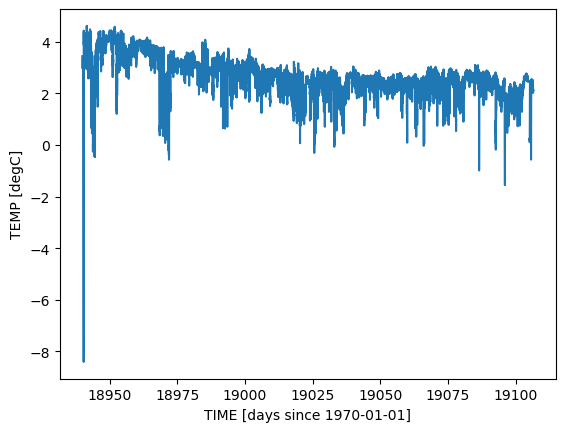

In [5]:
ds.TEMP.plot()


>.. or use functionality from `kval` which lets us flip thropugh variables and show e.g. temporal averages *(but may not work on all systems)*:


In [9]:
moored.plot(ds)

____

***So -*** we have now read the data with some basic metadata and gotten a basic dea of what it contains. We can now export directly to a NetCDF file. 

In subsequent notebooks, we will load the file we crate here and go on to do some post-processing and analysis, and we will save new updated versionsof the data as we go.
___

## Save to NetCDF

In [7]:
# Specify where we want to save the file to
out_path = '../../data/moored_CTD_test_data/intermediate_data/'

# Specify a file name
out_name = 'AT800_21_22_CONCERTO_60595_99m_from_raw.nc'

.. and export to NetCDF

In [8]:
moored.to_netcdf(ds, out_path, out_name)

Updated history attribute. Current content:
---
2021-11-08 - 2022-04-24: Data collection.
2026-06-11: Data read from .rsk file to xarray Dataset using pyRSKtools+kval.
2026-06-11: Creation of this netcdf file.
---
Exported NetCDF file as: ../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_from_raw.nc


___

**All done!** Hopefully this produced a file - check that it was created where you expected it to.
___

Note that you can also export to other formats, e.g. a MATLAB data file:

    moored.to_mat(ds, 'path/dataset_as_mat.mat)

Here, we will stick with NetCDF.